NLP Sentiment Analysis

In [8]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import	seaborn as sns
from wordcloud import WordCloud
from collections	import Counter	
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem	import PorterStemmer
import warnings
warnings.filterwarnings('ignore')

In [9]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PRINCE\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
stop_words = set(stopwords.words('english'))

In [14]:
reviews = pd.read_csv('P652-Dataset.csv', encoding='latin-1')

In [15]:
reviews

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [16]:
reviews.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [17]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [18]:
reviews.describe()

,rating
count,1440.000000
mean,3.173611
std,1.584453
min,1.000000
25%,1.000000
50%,4.000000
75%,5.000000
max,5.000000


In [19]:
reviews.shape

(1440, 3)

In [20]:
reviews.columns

Index(['title', 'rating', 'body'], dtype='object')

In [21]:
reviews.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [22]:
reviews = reviews.drop_duplicates()

In [23]:
reviews = reviews.dropna(subset=['rating', 'body'])

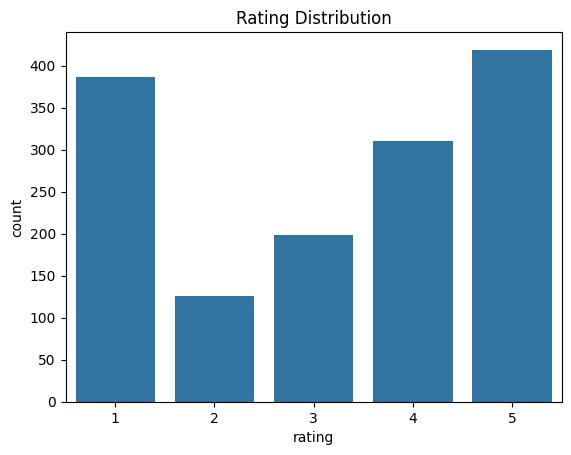

In [24]:
sns.countplot(x='rating', data=reviews)
plt.title("Rating Distribution")
plt.show()

In [25]:
print(reviews['rating'].value_counts())

rating
5    419
1    386
4    310
3    199
2    126
Name: count, dtype: int64


In [26]:
def convert_sentiment(rating):
    return 1 if rating >= 3 else 0

In [ ]:
reviews['sentiment'] = reviews['rating'].apply(convert_sentiment)

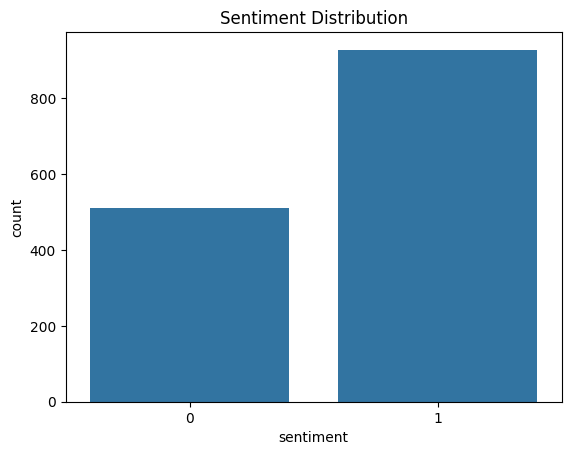

In [28]:
sns.countplot(x='sentiment', data=reviews)
plt.title("Sentiment Distribution")
plt.show()


In [29]:

print(reviews['sentiment'].value_counts())

sentiment
1    928
0    512
Name: count, dtype: int64


In [30]:
reviews['word_count'] = reviews['body'].apply(lambda x: len(str(x).split()))

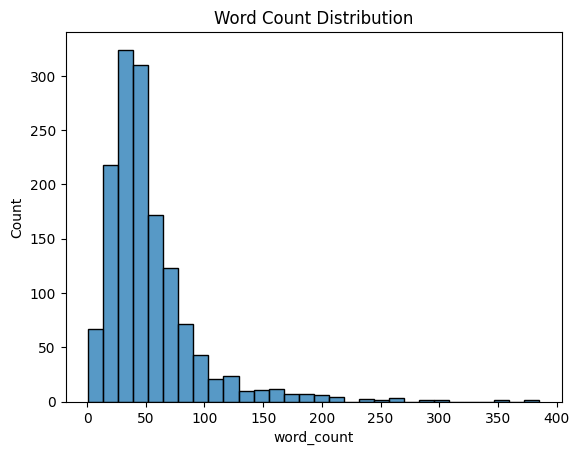

In [31]:
sns.histplot(reviews['word_count'], bins=30)
plt.title("Word Count Distribution")
plt.show()

In [32]:
reviews['char_count'] = reviews['body'].apply(len)


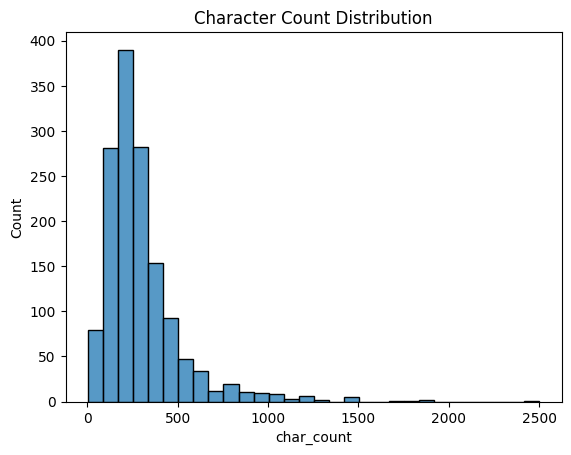

In [33]:
sns.histplot(reviews['char_count'], bins=30)
plt.title("Character Count Distribution")
plt.show()

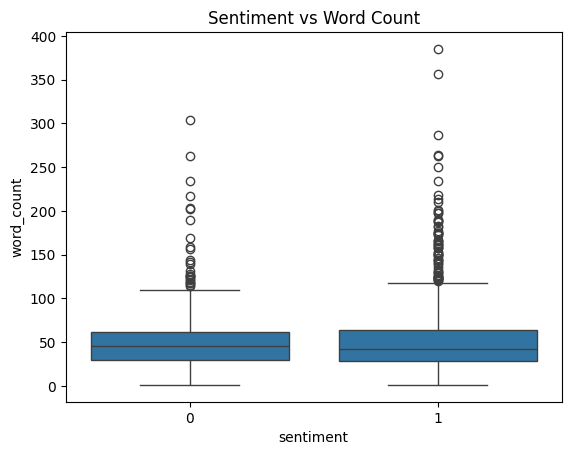

In [34]:
sns.boxplot(x='sentiment', y='word_count', data=reviews)
plt.title("Sentiment vs Word Count")
plt.show()

In [35]:
from collections import Counter

all_words = " ".join(reviews['body']).split()
common_words = Counter(all_words).most_common(20)

common_df = pd.DataFrame(common_words, columns=['Word','Frequency'])
common_df

,Word,Frequency
0,is,2968
1,the,1751
2,and,1529
3,to,1251
4,for,1214
5,this,1174
6,phone,1099
7,a,1054
8,I,1043
9,not,1043


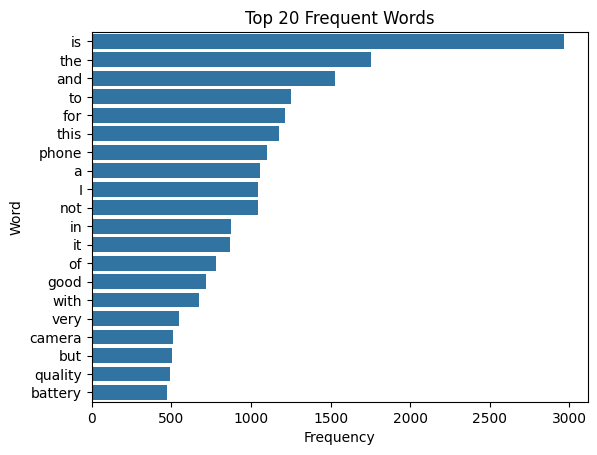

In [36]:
sns.barplot(x="Frequency", y="Word", data=common_df)
plt.title("Top 20 Frequent Words")
plt.show()

In [37]:
print("Average Rating:", reviews["rating"].mean())

Average Rating: 3.173611111111111


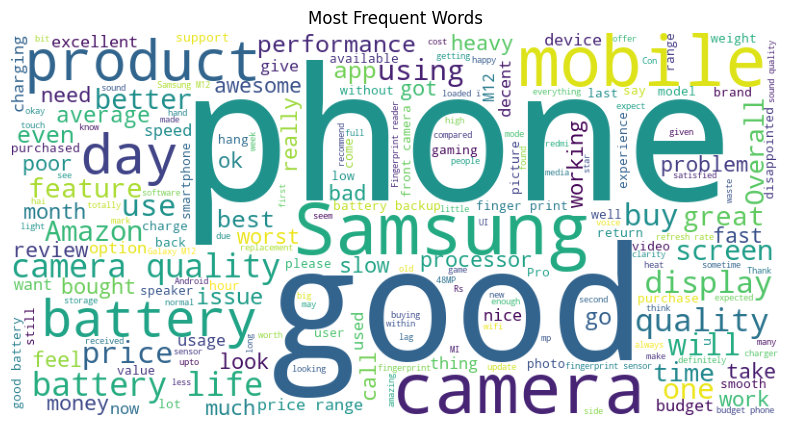

In [38]:
text = " ".join(reviews['body'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Frequent Words")
plt.show()

In [39]:
print("Duplicate rows:", reviews.duplicated().sum())

Duplicate rows: 0


In [40]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [41]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    return " ".join(words)

In [42]:
reviews['clean_text'] = reviews['body'].apply(clean_text)

In [118]:

from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(reviews['clean_text'])
y = reviews['sentiment']
print("TF-IDF shape:", X.shape)

TF-IDF shape: (1440, 5000)


Task-2 Model Building and Evaluation

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [73]:
# Logistic Regression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [74]:
lr_pred = lr_model.predict(X_test)

In [75]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Classification Report:\n", classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8333333333333334
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.59      0.73       111
           1       0.79      0.98      0.88       177

    accuracy                           0.83       288
   macro avg       0.88      0.79      0.81       288
weighted avg       0.86      0.83      0.82       288



In [76]:
#	Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [77]:
nb_pred = nb_model.predict(X_test)

In [78]:
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.7083333333333334


In [79]:
print("Classification Report:\n", classification_report(y_test, nb_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.25      0.40       111
           1       0.68      0.99      0.81       177

    accuracy                           0.71       288
   macro avg       0.82      0.62      0.60       288
weighted avg       0.79      0.71      0.65       288



In [80]:
#Support Vector Machine
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [81]:
svm_pred = svm_model.predict(X_test)

In [82]:
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("Classification Report:\n", classification_report(y_test, svm_pred))

SVM Accuracy: 0.8472222222222222
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.72      0.78       111
           1       0.84      0.93      0.88       177

    accuracy                           0.85       288
   macro avg       0.85      0.82      0.83       288
weighted avg       0.85      0.85      0.84       288



In [83]:
#Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [84]:
rf_pred = rf_model.predict(X_test)

In [85]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.8368055555555556
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.68      0.76       111
           1       0.82      0.94      0.88       177

    accuracy                           0.84       288
   macro avg       0.85      0.81      0.82       288
weighted avg       0.84      0.84      0.83       288



In [86]:
#Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [87]:
dt_pred = dt_model.predict(X_test)

In [88]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Classification Report:\n", classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.7326388888888888
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.53      0.61       111
           1       0.75      0.86      0.80       177

    accuracy                           0.73       288
   macro avg       0.72      0.70      0.70       288
weighted avg       0.73      0.73      0.72       288



In [89]:
#K-Nearest Neighbors
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [90]:
knn_pred = knn_model.predict(X_test)

In [91]:
print("KNN Accuracy:", accuracy_score(y_test, knn_pred))
print("Classification Report:\n", classification_report(y_test, knn_pred))

KNN Accuracy: 0.3854166666666667
Classification Report:
               precision    recall  f1-score   support

           0       0.39      1.00      0.56       111
           1       0.00      0.00      0.00       177

    accuracy                           0.39       288
   macro avg       0.19      0.50      0.28       288
weighted avg       0.15      0.39      0.21       288



In [123]:
cm = confusion_matrix(y_test, svm_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[ 80  31]
 [ 13 164]]


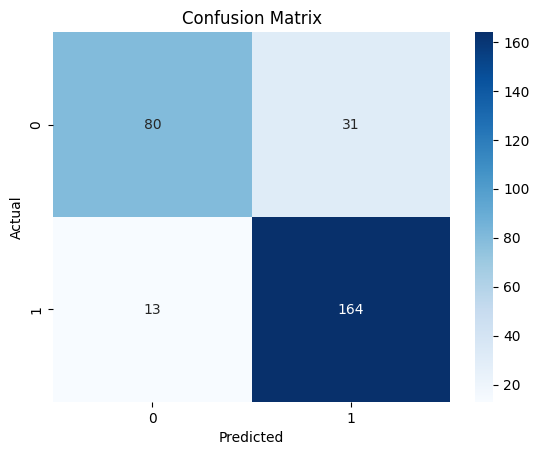

In [124]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [94]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Random Forest",
        "Decision Tree",
        "KNN"
    ],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.833333
1          Naive Bayes  0.708333
2                  SVM  0.847222
3        Random Forest  0.836806
4        Decision Tree  0.732639
5                  KNN  0.385417


In [121]:
import joblib
joblib.dump(svm_model,"svm_model.pkl")
joblib.dump(vectorizer,"tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [122]:
import os
print(os.path.exists("svm_model.pkl"))
print(os.path.exists("Tfidf_vectorizer.pkl"))

True
True
